# Anomaly Detection Dataset Generation

`make_anomaly_dataset` generates a dataset where *normal* samples follow a
smooth signal built from the same primitives used in the classification
module, while *anomalous* samples deviate by a larger noise term.

Labels: `0` = normal, `1` = anomaly.

This notebook demonstrates:
- A default sinusoidal + linear signal with 5% anomalies
- The effect of `anomaly_scale` on detectability
- A dataset built from a custom polynomial + sinusoidal signal
- Basic PyTorch `DataLoader` integration

In [ ]:
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset

from artificial_dataset import ClassifierMetrics, make_anomaly_dataset

## Default dataset: sinusoidal + linear signal with 5% anomalies

The default signal combines `sin(x) + 0.1 * x`. Normal samples cluster
tightly around the curve; anomalous samples scatter widely due to the
`anomaly_scale * noise_std` perturbation.

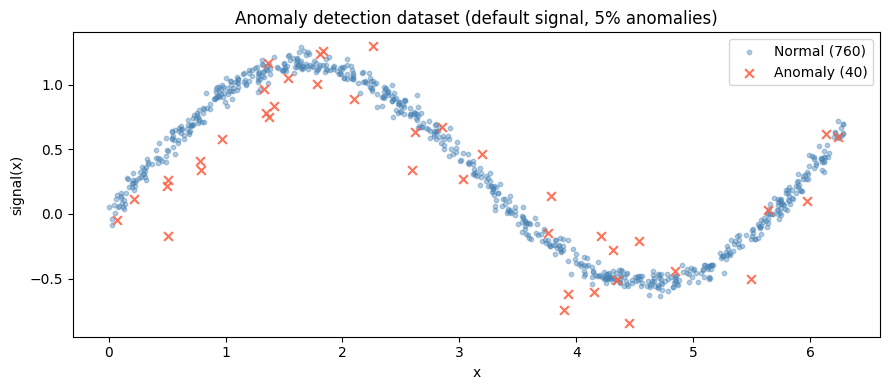

In [2]:
X, y = make_anomaly_dataset(n_samples=800, anomaly_fraction=0.05, random_state=0)

normal = y == 0
anomaly = y == 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(
    X[normal, 0],
    X[normal, 1],
    s=10,
    alpha=0.4,
    color="steelblue",
    label=f"Normal ({normal.sum().item()})",
)
ax.scatter(
    X[anomaly, 0],
    X[anomaly, 1],
    s=40,
    alpha=0.9,
    color="tomato",
    marker="x",
    label=f"Anomaly ({anomaly.sum().item()})",
)
ax.set_xlabel("x")
ax.set_ylabel("signal(x)")
ax.set_title("Anomaly detection dataset (default signal, 5% anomalies)")
ax.legend()
plt.tight_layout()
plt.show()

## Effect of `anomaly_scale` on detectability

`anomaly_scale` multiplies `noise_std` for anomalous samples.
Small values make anomalies hard to distinguish; large values produce
clear outliers.

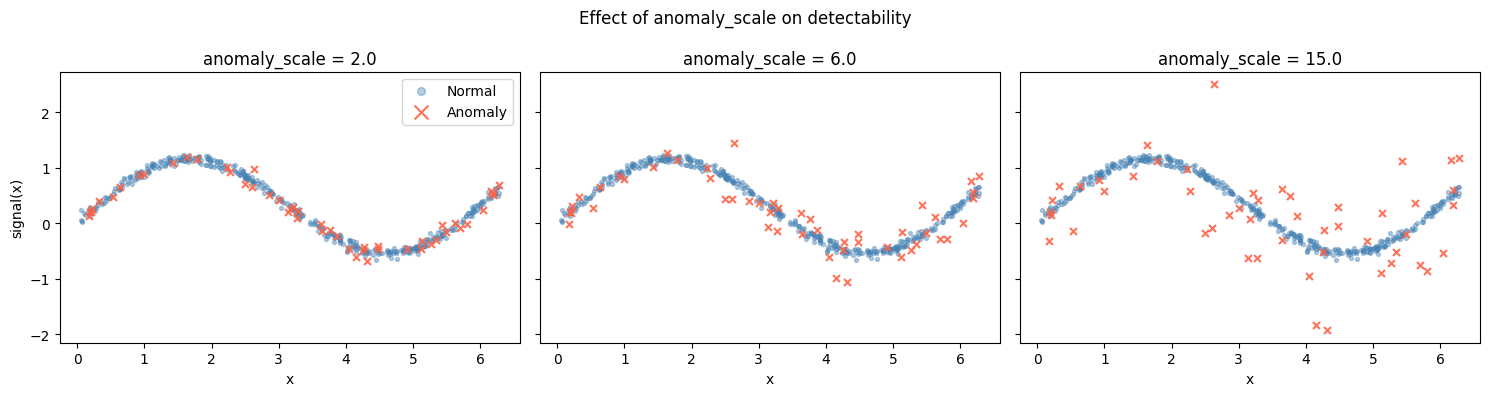

In [3]:
scales = [2.0, 6.0, 15.0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for i, scale in enumerate(scales):
    X_s, y_s = make_anomaly_dataset(
        n_samples=500, anomaly_fraction=0.1, anomaly_scale=scale, random_state=1
    )
    normal = y_s == 0
    anomaly = y_s == 1
    axes[i].scatter(
        X_s[normal, 0],
        X_s[normal, 1],
        s=8,
        alpha=0.4,
        color="steelblue",
        label="Normal",
    )
    axes[i].scatter(
        X_s[anomaly, 0],
        X_s[anomaly, 1],
        s=25,
        alpha=0.9,
        color="tomato",
        marker="x",
        label="Anomaly",
    )
    axes[i].set_title(f"anomaly_scale = {scale}")
    axes[i].set_xlabel("x")
axes[0].set_ylabel("signal(x)")
axes[0].legend(markerscale=2)
plt.suptitle("Effect of anomaly_scale on detectability")
plt.tight_layout()
plt.show()

## Custom signal shape: polynomial + sinusoidal

Any combination of `"linear"`, `"polynomial"`, and `"sinusoidal"` keys
can be passed as `signal_params` to define the underlying normal-behaviour
pattern.

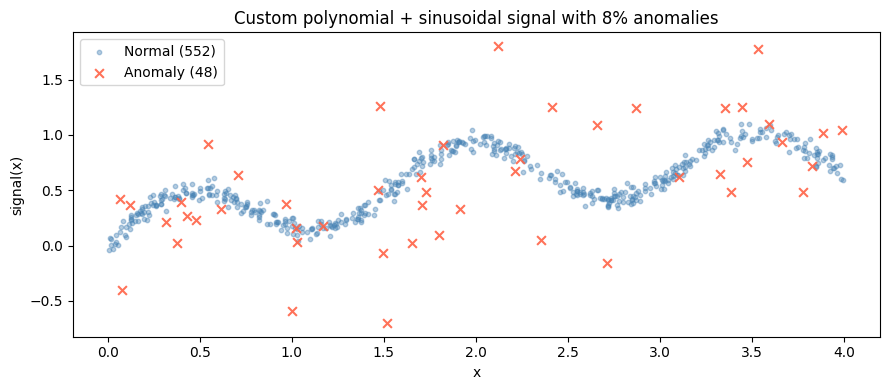

In [4]:
signal_params = {
    "polynomial": {"coefficients": [0.0, 0.5, -0.1, 0.005]},
    "sinusoidal": {"amplitude": 0.3, "frequency": 4.0, "phase": 0.0},
}

X_p, y_p = make_anomaly_dataset(
    n_samples=600,
    anomaly_fraction=0.08,
    noise_std=0.05,
    x_range=(0.0, 4.0),
    signal_params=signal_params,
    anomaly_scale=8.0,
    random_state=2,
)

normal = y_p == 0
anomaly = y_p == 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(
    X_p[normal, 0],
    X_p[normal, 1],
    s=10,
    alpha=0.4,
    color="steelblue",
    label=f"Normal ({normal.sum().item()})",
)
ax.scatter(
    X_p[anomaly, 0],
    X_p[anomaly, 1],
    s=40,
    alpha=0.9,
    color="tomato",
    marker="x",
    label=f"Anomaly ({anomaly.sum().item()})",
)
ax.set_xlabel("x")
ax.set_ylabel("signal(x)")
ax.set_title("Custom polynomial + sinusoidal signal with 8% anomalies")
ax.legend()
plt.tight_layout()
plt.show()

## PyTorch `DataLoader` integration

Both generators return plain `torch.Tensor` objects and integrate directly
with `TensorDataset` and `DataLoader` for training loops.

In [5]:
X_dl, y_dl = make_anomaly_dataset(n_samples=1000, anomaly_fraction=0.05, random_state=3)

dataset = TensorDataset(X_dl, y_dl)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

batch_features, batch_labels = next(iter(loader))
print(f"Dataset size         : {len(dataset)}")
print(f"Batches per epoch    : {len(loader)}")
print(f"Batch features shape : {batch_features.shape}")
print(f"Batch labels shape   : {batch_labels.shape}")
print(f"Normal in batch      : {(batch_labels == 0).sum().item()}")
print(f"Anomalies in batch   : {(batch_labels == 1).sum().item()}")

Dataset size         : 1000
Batches per epoch    : 16
Batch features shape : torch.Size([64, 2])
Batch labels shape   : torch.Size([64])
Normal in batch      : 60
Anomalies in batch   : 4


## Evaluating a classifier with `ClassifierMetrics`

`ClassifierMetrics` computes accuracy, macro-averaged precision, recall,
F1 score, and a confusion matrix.

For anomaly detection, the most convenient entry point is
`ClassifierMetrics.from_anomaly_indices`, which accepts the *index positions*
of the positive (anomaly) class — no need to build a full label vector
manually.  A plain Python `list` or a `torch.Tensor` are both accepted.

In [ ]:
# Generate a dataset and simulate a classifier that misses some anomalies
# and produces a few false positives.
X_ev, y_true = make_anomaly_dataset(
    n_samples=500, anomaly_fraction=0.1, random_state=10
)

true_indices = (y_true == 1).nonzero(as_tuple=True)[0]

# Simulate predictions: keep 80% of true anomalies, add 5 false positives.
torch.manual_seed(0)
kept = true_indices[torch.randperm(len(true_indices))[: int(0.8 * len(true_indices))]]
false_positives = torch.tensor([1, 7, 23, 200, 350])
pred_indices = torch.cat([kept, false_positives])

m = ClassifierMetrics.from_anomaly_indices(
    n_samples=500,
    true_indices=true_indices,
    pred_indices=pred_indices,
)

print(f"Accuracy  : {m.accuracy:.3f}")
print(f"Precision : {m.precision:.3f}")
print(f"Recall    : {m.recall:.3f}")
print(f"F1 score  : {m.f1_score:.3f}")
print()
print("Confusion matrix (rows = true, cols = predicted):")
print(m.confusion_matrix)